# `hw1`: Exploration of pulse oximetry data

Deadline: **Monday, November 4, 11:59 PM**. 
- Submit your completed notebook on your personal Github repository created when accepting the assignment.
- All cells must be executable and their outputs should not be erased before submission.
- Homeworks are carried out *individually*.

In [1]:
# Fill in this cell with your personal details:
# - Name: Dutailly Alexandre    
# - Student ID: S195855
# - Email: alexandre.dutailly@gmail.com

In this homework, you will have to load, clean, and explore pulse oximetry data from the [ OpenOximetry Repository](https://physionet.org/content/openox-repo/1.0.1). This dataset of oxygen desaturation studies notably includes oxygen saturation (so2 / SO2) measures from blood samples and unprocessed photoplethysmography (PPG) from pulse oximeters.

The goal of this first homework is to prepare the data and to perform some basic exploratory analysis. The same dataset will be used in the next homeworks, so it is important to understand the data and to prepare it properly.

All documentation about the dataset can be found on the dataset webpage and in the downloaded files.

First, create a [Physionet Account](https://physionet.org/register). Then, read and sign the [Data Use Agreement](https://physionet.org/sign-dua/openox-repo/1.0.1/). Finally, download the files in the [OpenOximetry Repository Files Section](https://physionet.org/content/openox-repo/1.0.1#files). Decompress the dataset in a directory named `data/` at the root of your project. Make sure to add `data/*` to your `.gitignore` file.

# Exercises

- Solve the exercises below by making the best use of the API offered in `numpy`, `pandas` and `matplotlib`.
- You will also need to use the `wfdb` library for reading and writing waveform data (see [WFDB Documentation](https://wfdb.readthedocs.io/en/latest/wfdb.html)).
- For plots, feel free to use `matplotlib`, `seaborn` or `pandas` built-in plotting functions.
- Follow the data visualization principles as best as possible to make your plots effective and readable.
- For each exercise, add Markdown cells to explain what you are doing and to discuss your results.

In [1]:
import warnings
import wfdb as wf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno 

warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
pd.set_option('display.max_columns', None)

pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

<div class="alert alert-success">
    
**Exercise**. Load the data from `data/patient.csv`, `data/encounter.csv`, and `data/bloodgas.csv` into dataframes. Visualise the raw data, understand the mearning of the different columns and values, drop or combine rows and columns if needed. Justify your choices.

The resulting dataframes should have unique values in columns `patient_id`, `encounter_id` and `('encounter_id', 'date', 'time')`, respectively. It may be preferable to merge columns `date` and `time` in a proper `datetime` column for the last dataframe.
    
</div>

<div class="alert alert-danger">
    
**Advice**. Read the dataset documentation in `data/OpenOximetry_Data_Dictionary_v1.0.0_*.csv`).
    
</div>

Verification of uniquenes :
'patient_id' is unique : True
'encounter_id' is unique : False
data cleanup n  encounter_df...
Duplicate deleted.

Verification of uniquenes in 'encounter_id' et 'datetime' :
0 duplicates find.

The 'datetime' column was created.



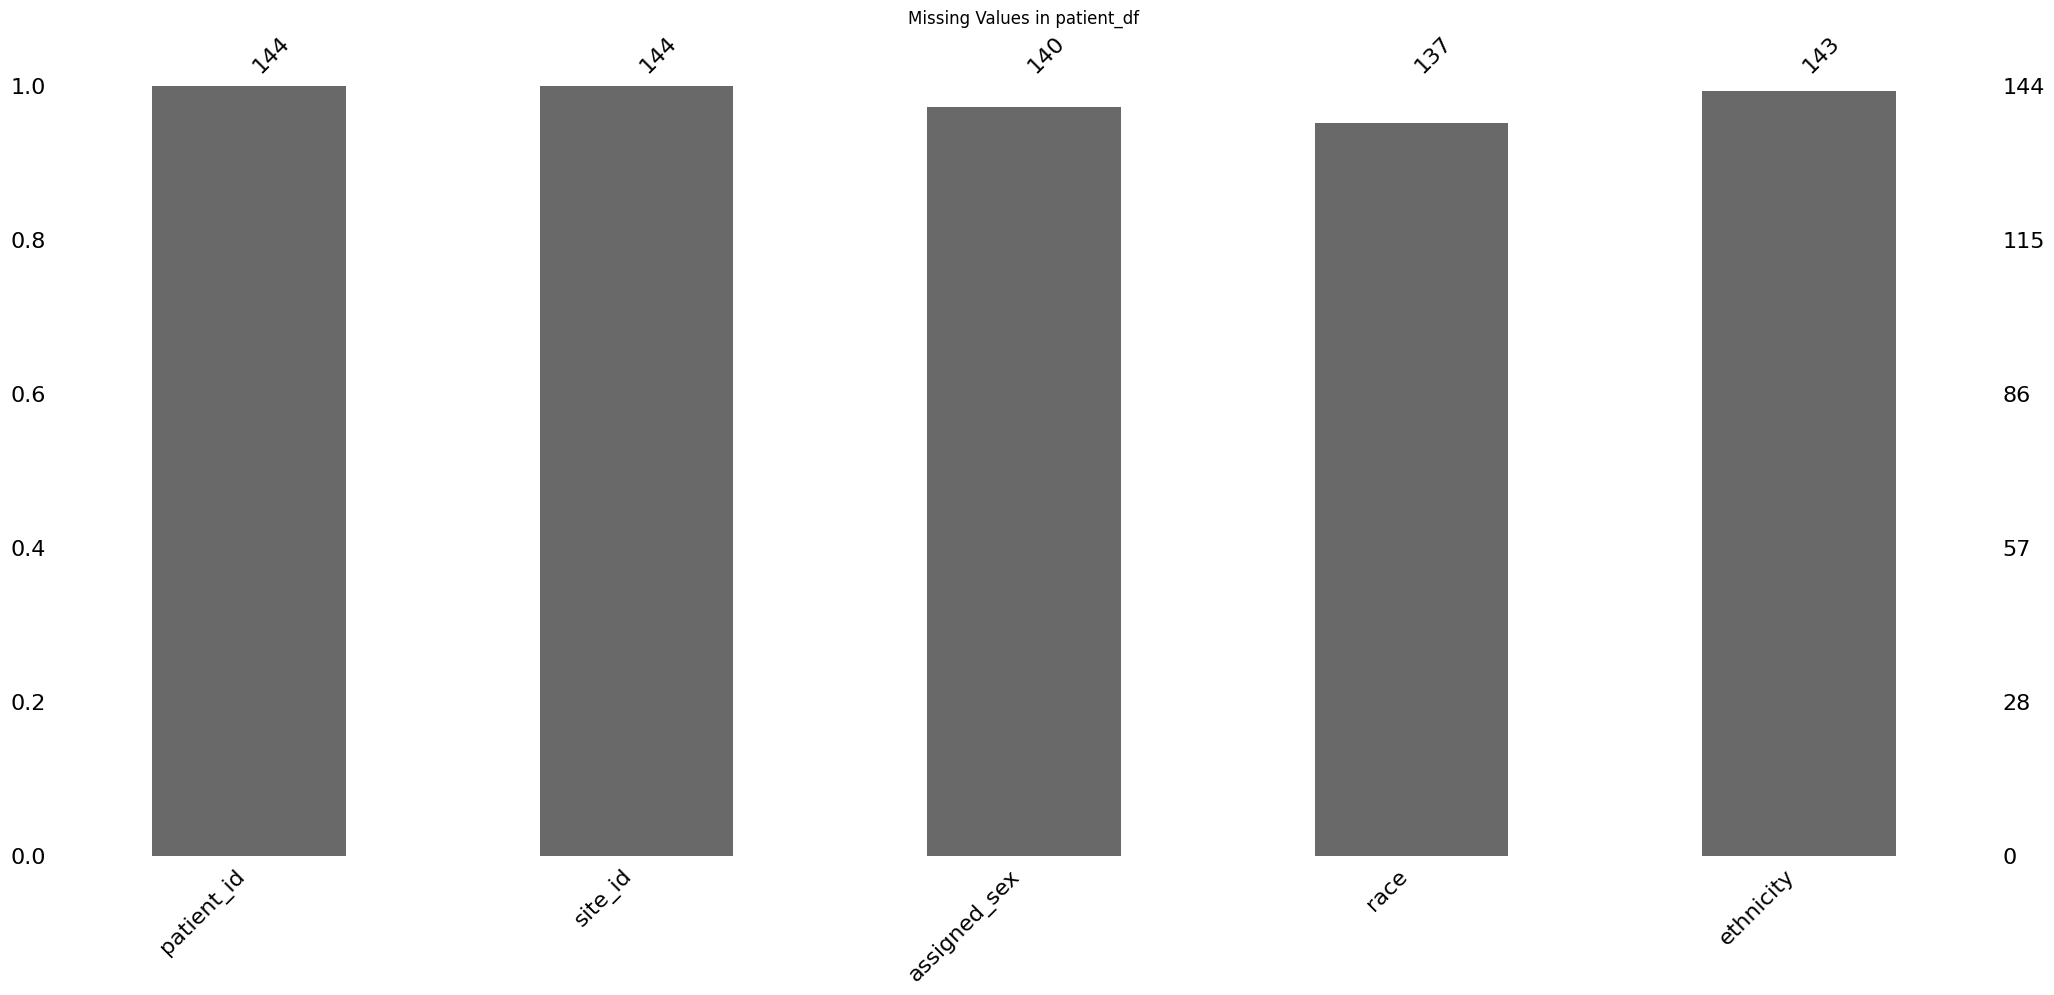

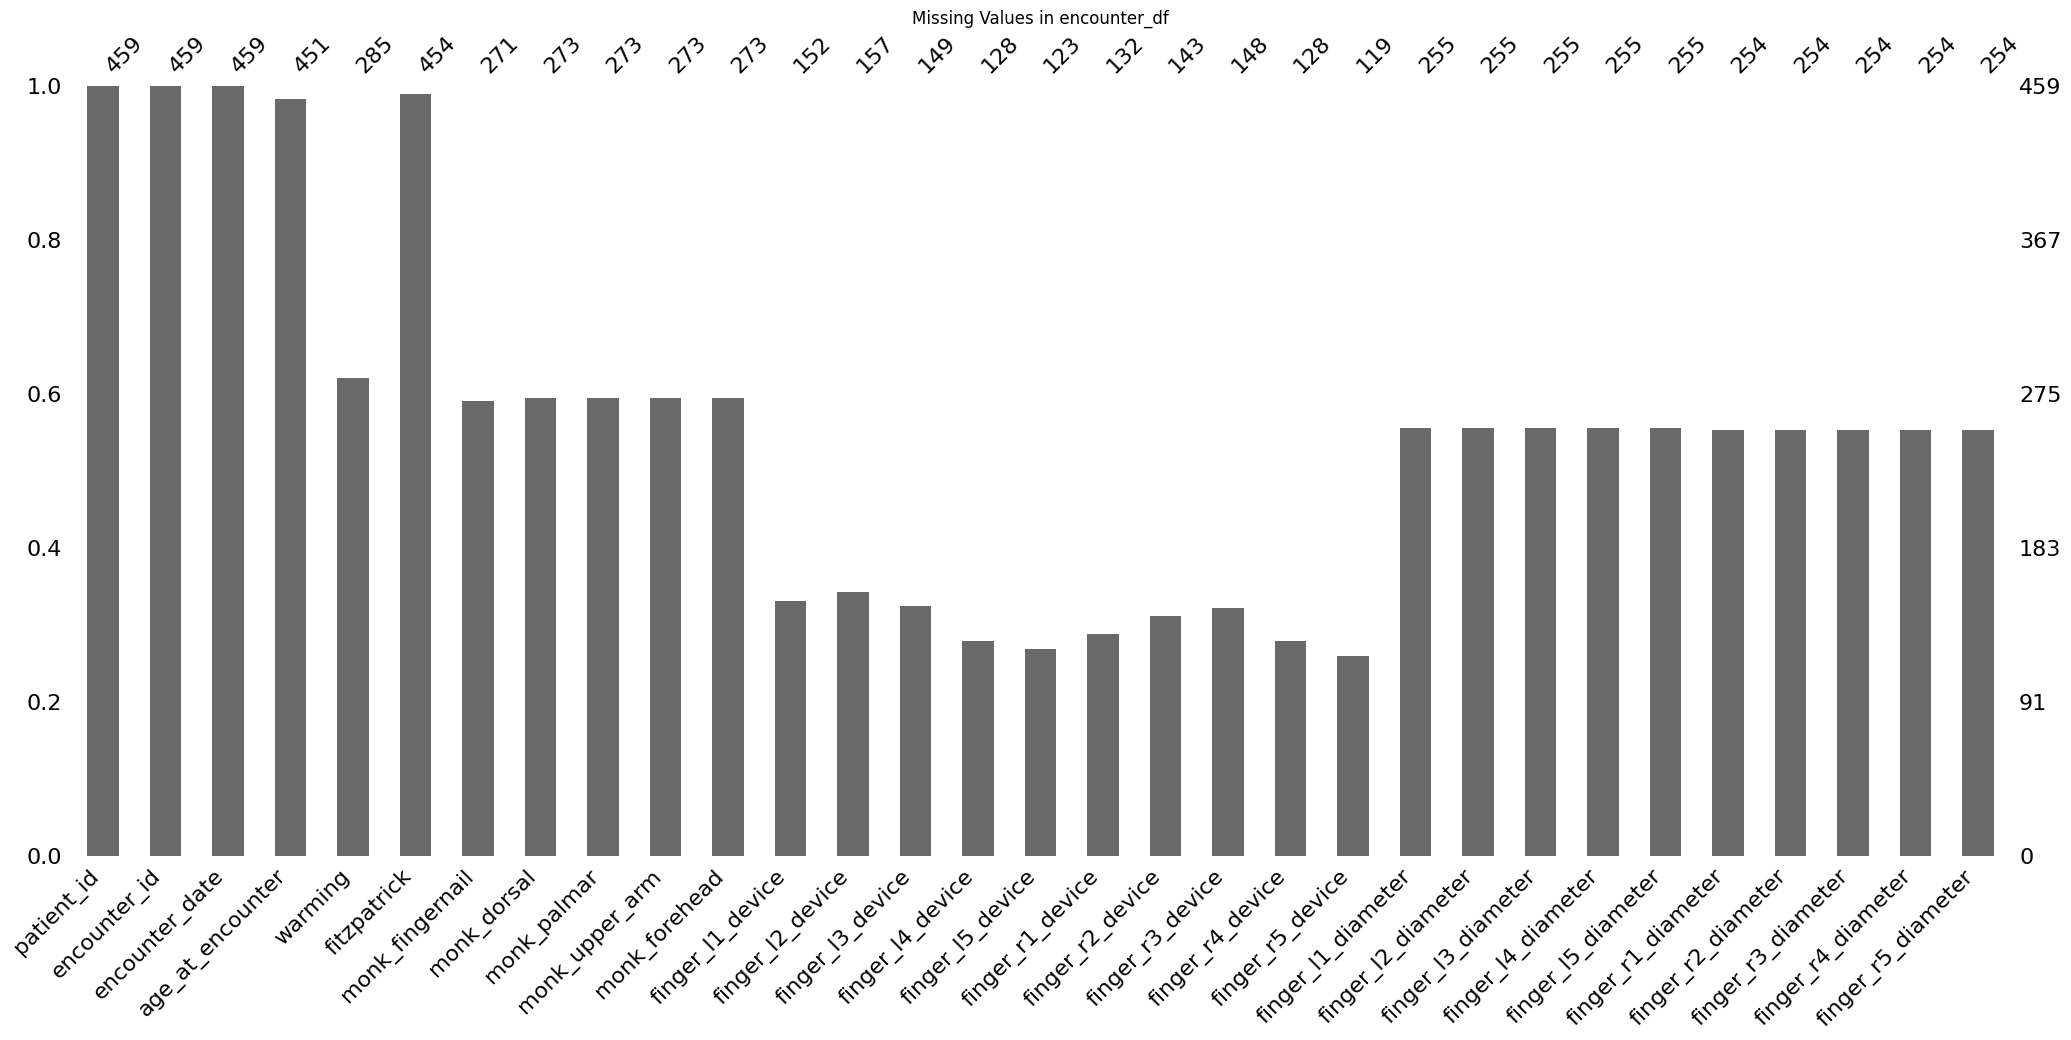

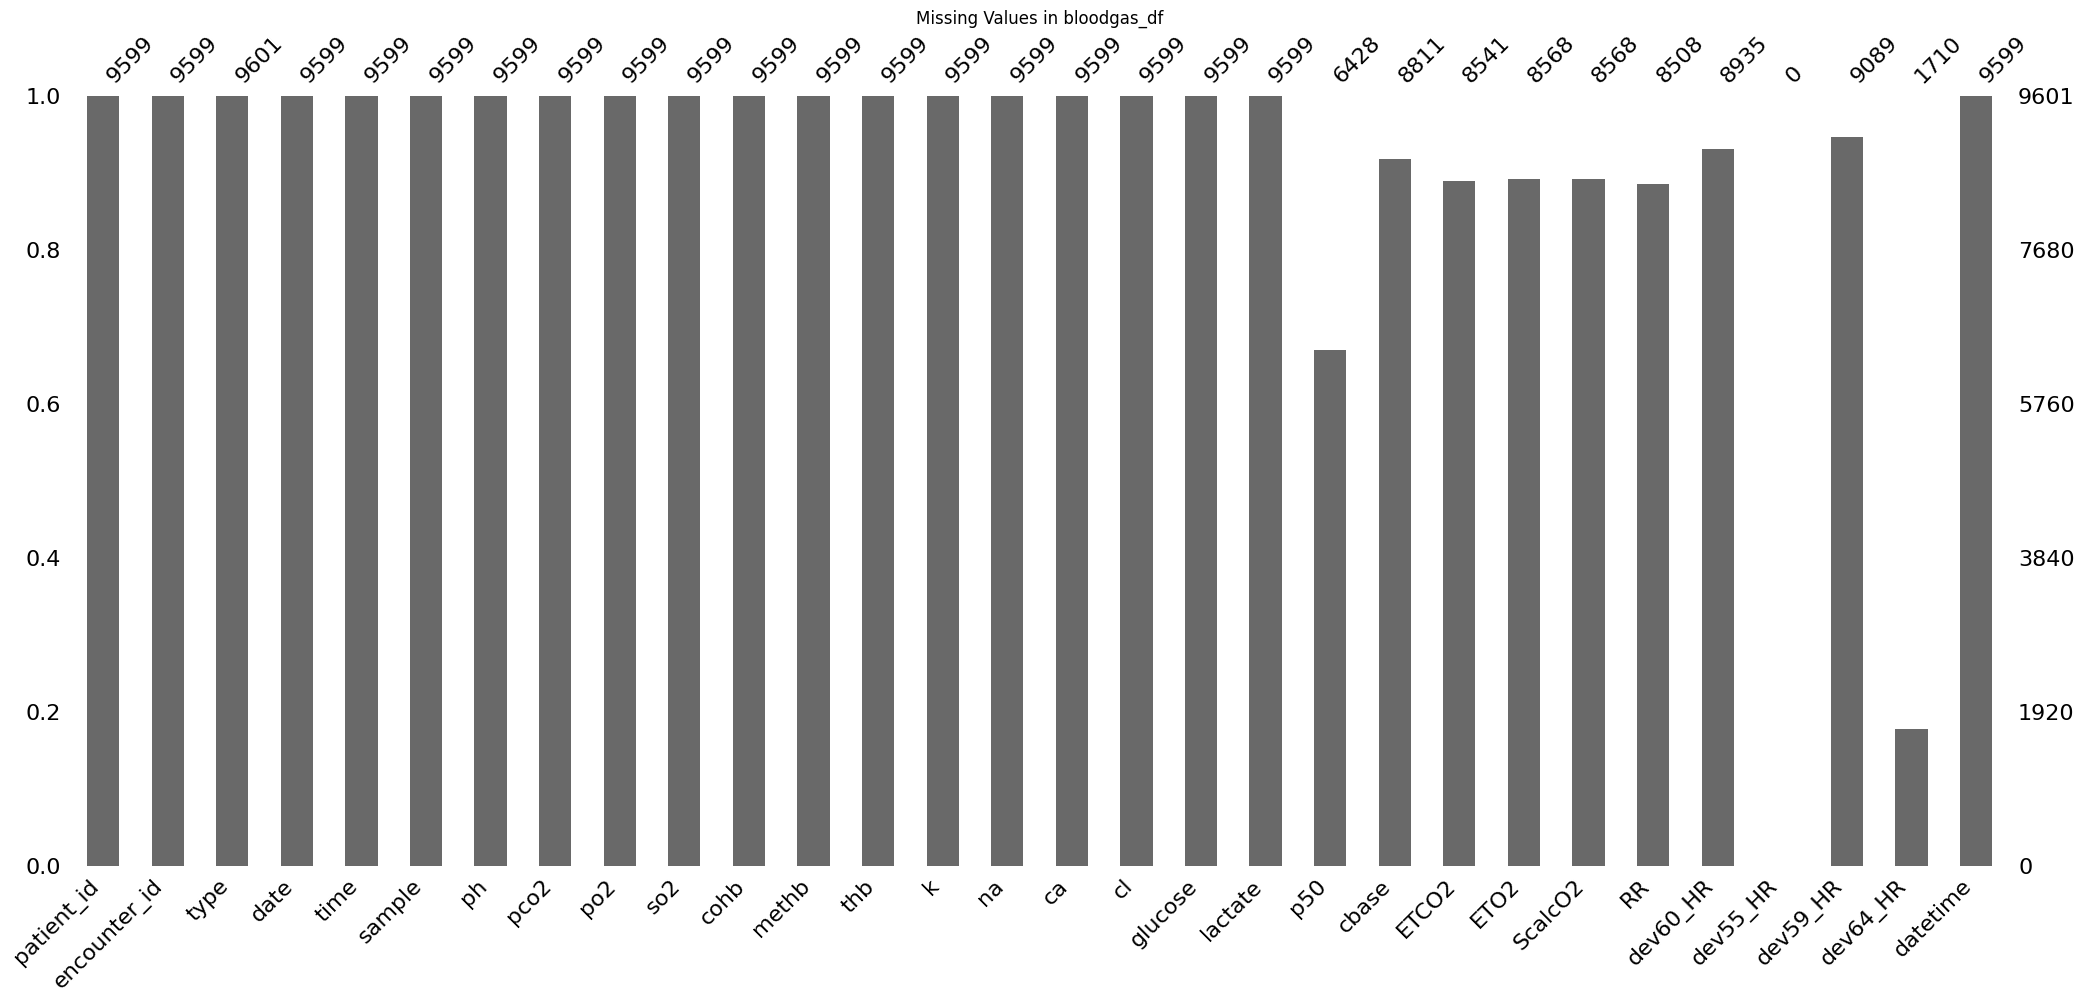

In [3]:

patient_df = pd.read_csv(r'data\patient.csv')
encounter_df = pd.read_csv(r'data\encounter.csv')
bloodgas_df = pd.read_csv(r'data\bloodgas.csv')

print("Verification of uniquenes :")
patient_unique = patient_df['patient_id'].is_unique
encounter_unique = 'encounter_id' in encounter_df.columns and encounter_df['encounter_id'].is_unique
print(f"'patient_id' is unique : {patient_unique}")
print(f"'encounter_id' is unique : {encounter_unique}")
print("data cleanup n  encounter_df...")
encounter_df = encounter_df.drop_duplicates(subset='encounter_id', keep='first')
print("Duplicate deleted.\n")

print("Verification of uniquenes in 'encounter_id' et 'datetime' :")
print(encounter_df[['encounter_id']].duplicated().sum(), "duplicates find.")


if 'date' in bloodgas_df.columns and 'time' in bloodgas_df.columns:
    bloodgas_df['datetime'] = pd.to_datetime(bloodgas_df['date'] + ' ' + bloodgas_df['time'])
    print("\nThe 'datetime' column was created.\n")



plt.figure(figsize=(10, 4))
msno.bar(patient_df)
plt.title("Missing Values in patient_df")
plt.show()

plt.figure(figsize=(10, 4))
msno.bar(encounter_df)
plt.title("Missing Values in encounter_df")
plt.show()

plt.figure(figsize=(10, 4))
msno.bar(bloodgas_df)
plt.title("Missing Values in bloodgas_df")
plt.show()





We removed all duplicates of `patient_id` from the data and merged the `date` and `time` columns into a single `datetime` column.  
We also examined the missingness of the data after removing duplicates.  
We can see that there are a lot of missing values, and it might be a good idea not to include the `dev55_HR`, `dev64_HR` and `p50`(we have more than 60% value but we don't have information on it) columns, given the small number of available samples. Furthermore, the names are not referenced in the `OpenOximetry_Data_Dictionary_v1.0.0_waveforms`. 
I have decided to remove them for the next exercices.





ValueError: 'rgb' is not a valid palette name

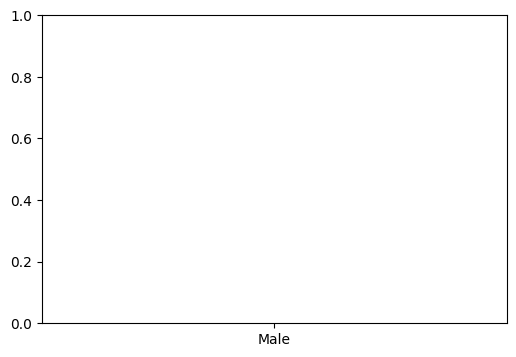

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=patient_df, x='assigned_sex', palette='pastel')
plt.title('Distribution du sexe')
plt.xlabel('Sexe')
plt.ylabel('Nombre d\'observations')
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(data=patient_df, x='ethnicity', palette='pastel')
plt.title('Distribution de l\'ethnicité')
plt.xlabel('Ethnicité')
plt.ylabel('Nombre d\'observations')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(data=patient_df, x='race', palette='pastel')
plt.title('Distribution de la race')
plt.xlabel('Race')
plt.ylabel('Nombre d\'observations')
plt.xticks(rotation=45)
plt.show()


In this plot, we have variables that provide us with information about patients according to their gender, ethnicity, and racial origin. The variable `assigned_sex` indicates the sex assigned at birth, generally noted as `Male` or `Female`. The variable `ethnicity` distinguishes individuals according to whether or not they identify as Hispanic or Latino, with apparent numerical coding (`1` for ‘Non-Hispanic’, `2` for ‘Hispanic’). Finally, the variable `race` groups perceived racial or continental origins, including categories such as `Asian`, `Caucasian`, `African American`, `Other/Multiracial`, etc.

The plots above show that the gender is relatively balanced, with a slight majority of women in the sample. In terms of ethnicity, the majority of patients is non-Hispanic, with Hispanic patients being significantly underrepresented. Regarding the variable `race`, there is notable diversity in the responses, but also the presence of numerical values such as `1`, `2`, `4`, `10`, which seem inconsistent with the expected text categories and a lack of information for a proper understanding of this variable.

<div class="alert alert-success">
    
**Exercise**. Now that the dataset have been loaded with unique identifier columns, merge them appropriately. Then, only select the following columns: `
    'encounter_id', 'patient_id', 'datetime', 'sample', 'assigned_sex', 'race', 'ethnicity', 'age_at_encounter', 'warming', 'ph', 'pco2', 'po2', 'so2', 'cohb', 'methb', 'thb', 'k', 'na', 'ca', 'cl', 'glucose', 'lactate', 'p50', 'cbase', 'ETCO2', 'ETO2', 'ScalcO2', 'RR', 'dev55_HR', 'dev59_HR', 'dev60_HR', 'dev64_HR', 'type'`.

</div>

In [6]:
merged_df = pd.merge(patient_df, encounter_df, on='patient_id', how='inner')

merged_df = pd.merge(merged_df, bloodgas_df, on=['patient_id', 'encounter_id'], how='inner')

columns_to_select = [
    'encounter_id', 'patient_id', 'datetime', 'sample', 'assigned_sex', 'ethnicity',
    'age_at_encounter', 'warming', 'ph', 'pco2', 'po2', 'so2', 'cohb', 'methb', 'thb',
    'k', 'na', 'ca', 'cl', 'glucose', 'lactate', 'cbase', 'ETCO2', 'ETO2', 'ScalcO2',
    'RR', 'dev59_HR', 'dev60_HR', 'type'
]


final_df = merged_df[columns_to_select]


final_df = final_df.groupby(['encounter_id', 'patient_id', 'datetime'], as_index=False).agg(lambda x: x.mean() if pd.api.types.is_numeric_dtype(x) else x.iloc[0])

print("Nombre de lignes après sup des doublons :", len(final_df))
print(final_df.head())


Nombre de lignes après sup des doublons : 5983
                                                       encounter_id  \
0  026237b8b5542bcc94e106231d499ee3bae833633c4d068b7b56fed33914ff12   
1  026237b8b5542bcc94e106231d499ee3bae833633c4d068b7b56fed33914ff12   
2  026237b8b5542bcc94e106231d499ee3bae833633c4d068b7b56fed33914ff12   
3  026237b8b5542bcc94e106231d499ee3bae833633c4d068b7b56fed33914ff12   
4  026237b8b5542bcc94e106231d499ee3bae833633c4d068b7b56fed33914ff12   

                                                         patient_id  \
0  79e4923e229bcb0b85d5cd87a55d73145a4e07c603e3a911e546f778945c9dba   
1  79e4923e229bcb0b85d5cd87a55d73145a4e07c603e3a911e546f778945c9dba   
2  79e4923e229bcb0b85d5cd87a55d73145a4e07c603e3a911e546f778945c9dba   
3  79e4923e229bcb0b85d5cd87a55d73145a4e07c603e3a911e546f778945c9dba   
4  79e4923e229bcb0b85d5cd87a55d73145a4e07c603e3a911e546f778945c9dba   

             datetime  sample assigned_sex  ethnicity  age_at_encounter  \
0 2223-05-23 09:28:00   

<div class="alert alert-success">
    
**Exercise**. If necessary, filter the data to remove outliers or abnormal values. Explain your approach and rationale.

</div>

Due to my lack of expertise in the medical field and the absence of team members to consult regarding physiologically accurate value ranges, I opted for a statistical approach to identify and remove outliers. Specifically, I applied the Interquartile Range (IQR) method, a robust and widely used technique for outlier detection. This method relies on the distribution of values, removing observations that fall outside 1.5 times the IQR above the third quartile or below the first quartile.

We chose to apply the interquartile range (IQR) method only to the following variables: `ph`, `pco2`, `po2`, `so2`, `cohb`, `methb`, `RR`, `thb`, `cbase`, `ETCO2`, `ETO2`, `dev59_HR` and `dev60_HR`.  
These variables correspond to physiological measurements for which it is useful to identify and treat unusual values, as they may indicate measurement errors or specific medical conditions.  

The other variables were not analysed using this method, either because they are categorical (such as `ethnicity` or `warming`), because they are used solely as identifiers (`datetime`, `sample`) or because they always have the same value (`type`). In these cases, the IQR would not provide relevant information for detecting unusual values.




In [7]:
def remove_outliers_iqr(df, columns):
    initial_count = len(df)
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    final_count = len(df)
    removed_count = initial_count - final_count
    print(f"Nombre total de lignes supprimées : {removed_count}")
    return df

final_df = remove_outliers_iqr(final_df, ['ph', 'pco2', 'po2', 'so2', 'cohb', 'methb', 'RR', 'thb', 'cbase', 'ETCO2', 'ETO2', 'dev59_HR', 'dev60_HR'])



Nombre total de lignes supprimées : 1977


<div class="alert alert-success">
    
**Exercise**. Compute descriptive or summary statistics of each individual column of the dataset. Comment on the results.
    
</div>

In [8]:
final_df.describe()


,datetime,sample,ethnicity,age_at_encounter,warming,ph,pco2,po2,so2,cohb,methb,thb,k,na,ca,cl,glucose,lactate,cbase,ETCO2,ETO2,ScalcO2,RR,dev59_HR,dev60_HR,type
count,4006,4006.000000,3991.000000,3930.000000,3628.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.000000,4006.0
mean,2181-10-22 06:08:15.561657344,13.964096,1.101478,27.353690,0.653252,7.426092,39.419130,52.362872,84.569433,0.907564,0.601706,13.344512,3.903291,139.987061,1.179422,105.185139,9.189170,0.797133,1.481066,38.629044,55.266366,84.795775,13.348352,83.512003,83.762606,1.0
min,2123-12-28 13:41:00,1.000000,1.000000,17.000000,0.000000,7.338500,30.000000,30.800000,64.000000,0.450000,0.300000,9.250000,3.200000,133.000000,0.970000,100.000000,4.400000,0.200000,-2.950000,28.734518,33.583164,66.217494,3.000000,47.000000,47.000000,1.0
25%,2152-11-15 10:06:15.000000512,7.666667,1.000000,23.000000,0.000000,7.405000,37.100000,40.500000,77.000000,0.800000,0.500000,12.100000,3.700000,139.000000,1.160000,104.000000,5.200000,0.500000,0.333333,36.143033,43.707246,78.271933,8.000000,74.000000,74.000000,1.0
50%,2174-01-07 10:00:30,14.000000,1.000000,25.000000,1.000000,7.427833,39.300000,48.000000,85.100000,0.900000,0.600000,13.400000,3.900000,140.000000,1.180000,105.000000,5.600000,0.700000,1.600000,38.410203,50.919970,85.031499,9.000000,82.666667,83.000000,1.0
75%,2210-10-05 11:05:44.999999488,20.000000,1.000000,27.000000,1.000000,7.446000,41.687500,62.700000,92.700000,1.000000,0.700000,14.600000,4.050000,141.000000,1.200000,106.000000,6.400000,1.000000,2.600000,40.928969,64.825748,92.051262,20.000000,93.000000,93.500000,1.0
max,2241-08-02 15:07:00,29.500000,2.000000,47.000000,1.000000,7.511500,48.750000,97.400000,98.500000,1.350000,0.966667,17.100000,9.700000,144.000000,1.360000,111.000000,93.800000,2.600000,5.900000,48.602355,95.650178,97.939648,36.000000,122.000000,122.500000,1.0
std,NaN,7.178026,0.301999,6.279329,0.476000,0.029740,3.361334,14.343261,8.583262,0.169465,0.130730,1.486473,0.300177,1.349303,0.034213,1.839018,12.972551,0.379443,1.647624,3.685589,14.136487,7.810061,6.393776,13.922310,14.021608,0.0


After applying the interquartile range (IQR) method, we compared the selected continuous variables `ph`, `pco2`, `po2`, `so2`, `cohb`, `methb`, `RR`, `thb`, `cbase`, `ETCO2`, `ETO2`, `dev59_HR` and `dev60_HR`.  

The `ph` and `cohb` are the variables that vary the least, and their values are very close to the mean. Conversely, `po2` and `ETO2` continue to vary significantly even after processing, suggesting that their values are naturally more dispersed.  
The respiration-related variables `RR`, `ETCO2` and `ETO2` also show differences. `RR` remains within a wider range of values than `ETCO2`, while `ETO2` remains the most variable of this group.  

For blood measurements, thb varies more than methb, which shows that these two parameters do not have the same value profile.  
The two heart rate measurements `dev59_HR` and `dev60_HR` are very similar in terms of average and variation, which shows that they provide virtually the same information.  

We can see that even after removing the extreme values with the IQR, some variables still show a wide variation, while others are much more stable.


<div class="alert alert-success">
    
**Exercise**. Analyze and visualize the pairwise correlations between the columns of the dataset. Select an appropriate subset of the columns for which measuring correlations makes sense. Comment on some expected or unexpected correlations.

Next, by focusing on bloodsamples at index `sample=1`, `sample=5` and `sample=10` throughout the desaturation studies (decreasing saturation), display the scatter plots of some interesting variable pairs (e.g., oxygen saturation, age, sex, etc). Comment on the results.

</div>

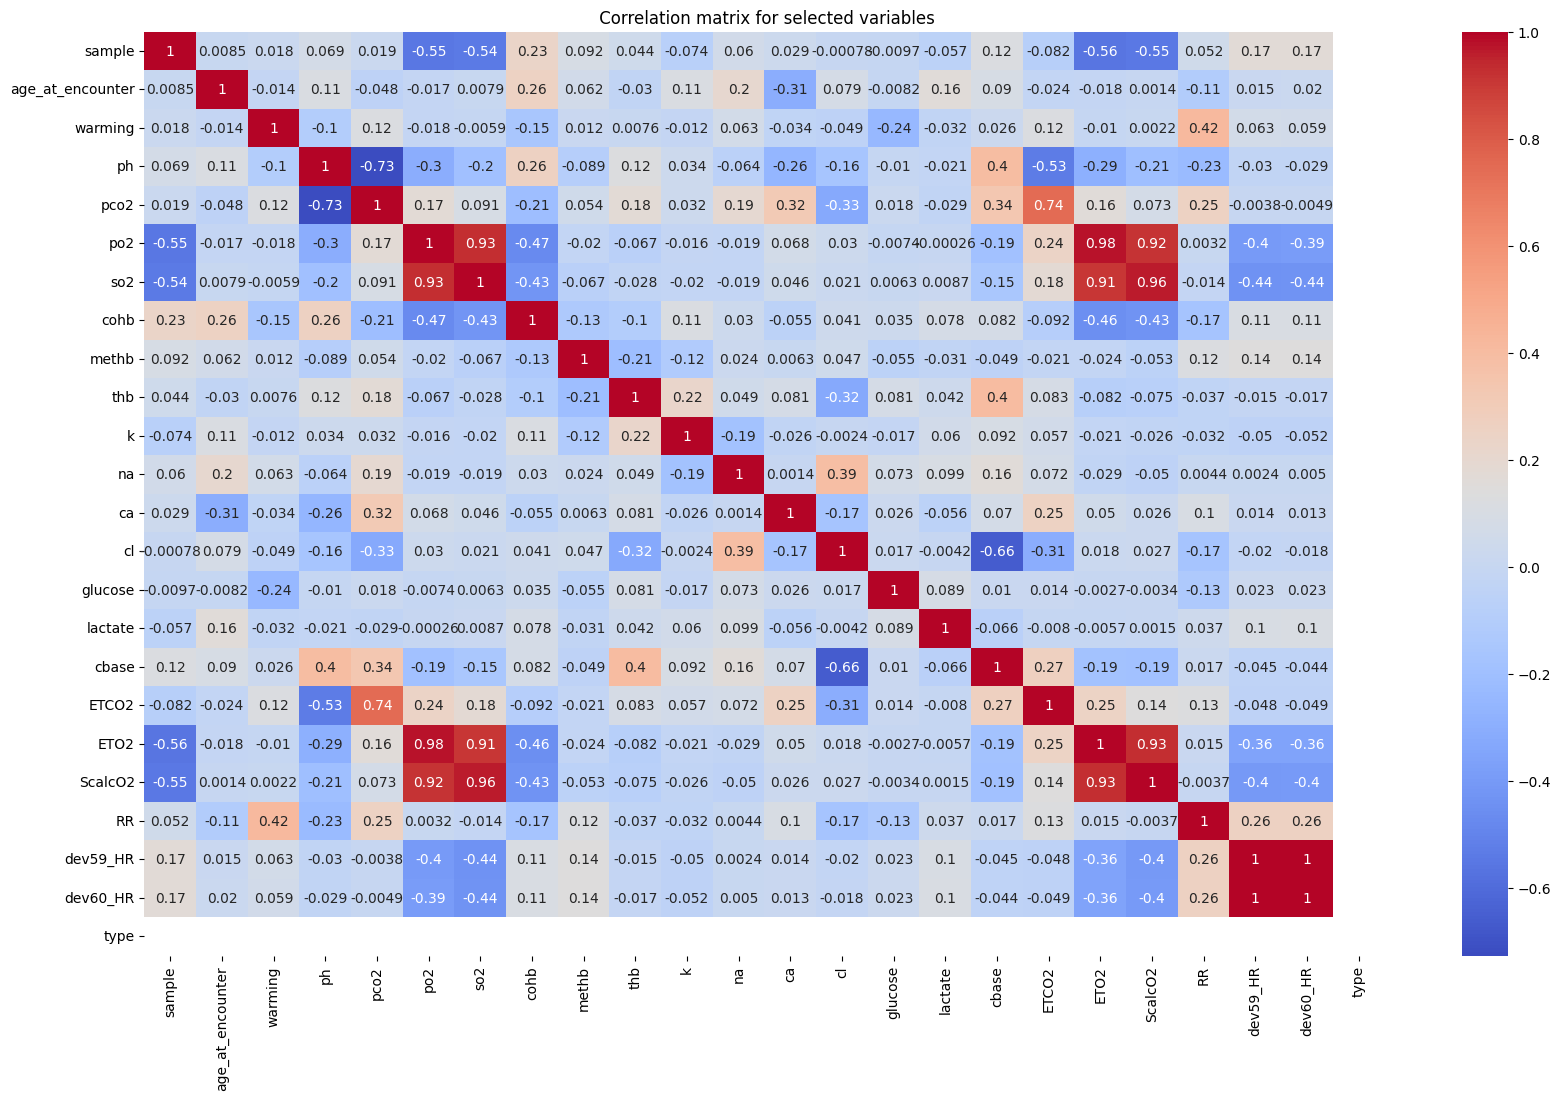

In [9]:
correlation_matrix = final_df[['sample',
    'age_at_encounter', 'warming', 'ph', 'pco2', 'po2', 'so2', 'cohb', 'methb', 'thb',
    'k', 'na', 'ca', 'cl', 'glucose', 'lactate', 'cbase', 'ETCO2', 'ETO2', 'ScalcO2',
    'RR', 'dev59_HR', 'dev60_HR', 'type'
]].corr()

plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title(" Correlation matrix for selected variables")
plt.show()




I decided to apply the correlation matrix to the variables I chose to keep in the previous exercises.However, I removed variables that contained non-numerical and identification information.

This correlation matrix highlights several notable relationships between the clinical variables measured. First, there is a strong positive correlation between partial oxygen pressure ($po_{2}$) and oxygen saturation ($so_{2}$), with a coefficient of 0.93. This relationship reflects the expected link between the amount of oxygen dissolved in the blood and its transport by haemoglobin.

Conversely, carbon dioxide pressure ($pCO_{2}$) and blood pH show a marked negative correlation (r = –0.73), illustrating the acidifying impact of $CO_{2}$ on the blood environment. pH also shows a moderate correlation with base excess (cbase), with a coefficient of 0.40.

It should be noted that $ETCO_{2}$ (exhaled $CO_{2}$ pressure) correlates well with $pCO_{2}$ (r = 0.74). On the other hand, an exceptionally high correlation (r = 0.98) is observed between ETCO₂ (exhaled oxygen) and pO₂, which may suggest redundancy between the two measurements.

Finally, the variables `dev59_HR` and `dev60_HR`, both of which are supposed to reflect heart rate, are perfectly correlated (r = 1.00). 


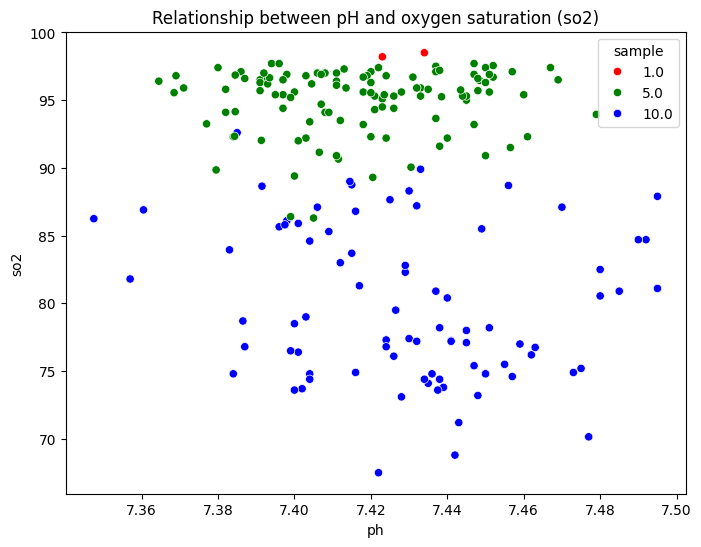

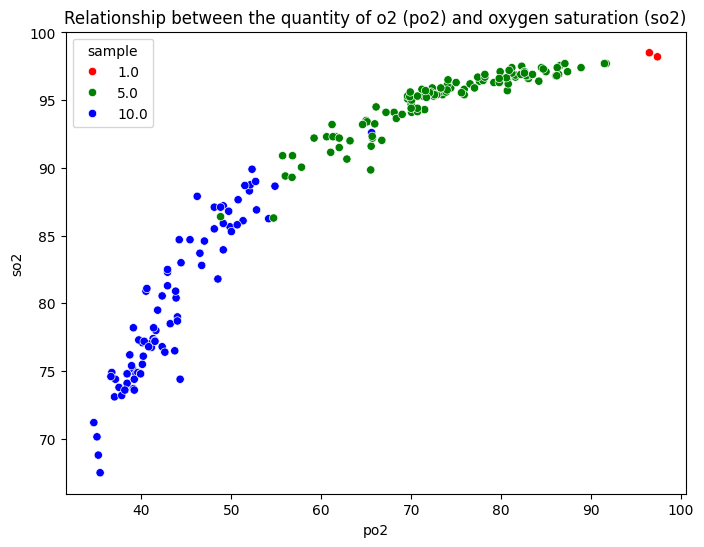

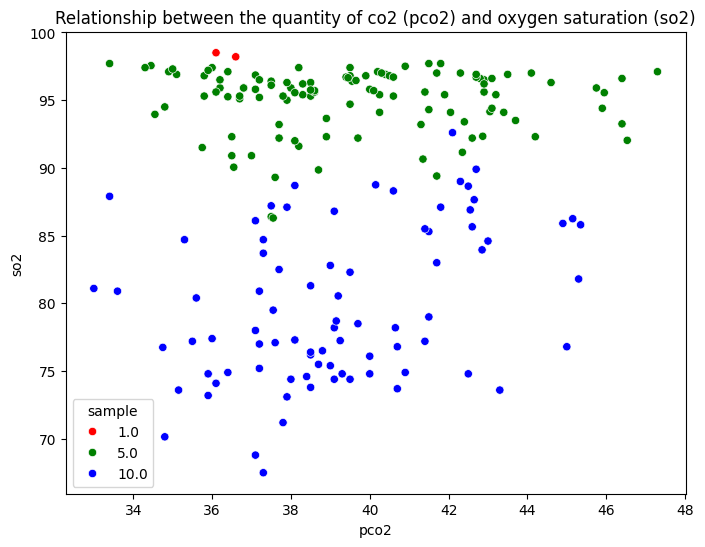

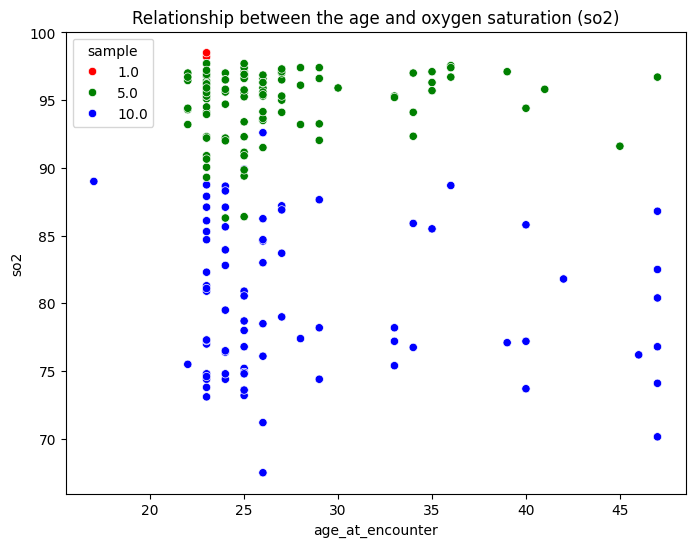

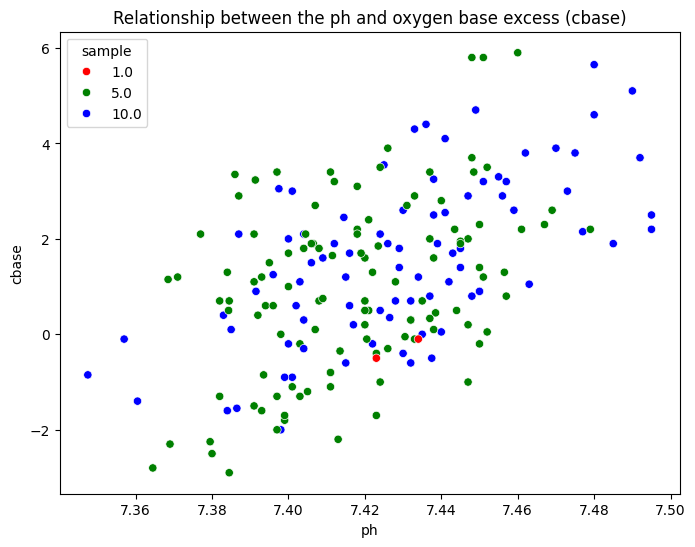

In [10]:
samples_of_interest = final_df[final_df['sample'].isin([1, 5, 10])]
custom_palette = {1: "red", 5: "green", 10: "blue"}

plt.figure(figsize=(8, 6))
sns.scatterplot(x='ph', y='so2', hue='sample', data=samples_of_interest, palette=custom_palette)
plt.title("Relationship between pH and oxygen saturation (so2)")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='po2', y='so2', hue='sample', data=samples_of_interest, palette=custom_palette)
plt.title("Relationship between the quantity of o2 (po2) and oxygen saturation (so2)")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='pco2', y='so2', hue='sample', data=samples_of_interest, palette=custom_palette)
plt.title("Relationship between the quantity of co2 (pco2) and oxygen saturation (so2)")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='age_at_encounter', y='so2', hue='sample', data=samples_of_interest, palette=custom_palette)
plt.title("Relationship between the age and oxygen saturation (so2)")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='ph', y='cbase', hue='sample', data=samples_of_interest, palette=custom_palette)
plt.title("Relationship between the ph and oxygen base excess (cbase)")
plt.show()

Focusing on the three key sampling times (sample = 1, 5 and 10), I plotted several scatter plots to highlight the evolution of desaturation over the course of the study. The `PO2 vs SO2` graph reveals a linear decrease in oxygenation, with the red points (first sample) in the high pressure and high saturation zone, the green points (fifth) in the middle, and the blue points (tenth) more clustered towards the low values, clearly illustrating the loss of oxygenation capacity.  

The relationships between pH vs SO2 and PCO2 vs SO2 confirm this link in a more loose manner. A slightly higher pH is accompanied on average by slightly better saturation, while an increase in $PaCO_{2}$ results in lower saturation, demonstrating the acidifying effect of $CO_{2}$ on the binding of oxygen to haemoglobin.  

To check whether other factors could influence desaturation, I also plotted `age vs SO2`: the vertical dispersion remains comparable for each `sample`, suggesting that age does not explain the variation in saturation in this cohort. Finally, the `pH vs Base Excess (cBase)` cloud shows that, despite desaturation, the metabolic buffer status evolves in a relatively parallel manner across the three samples, without any sudden changes, confirming that the main driver of the decrease in saturation remains the alteration in gas exchange (PO2, PCO2, pH).

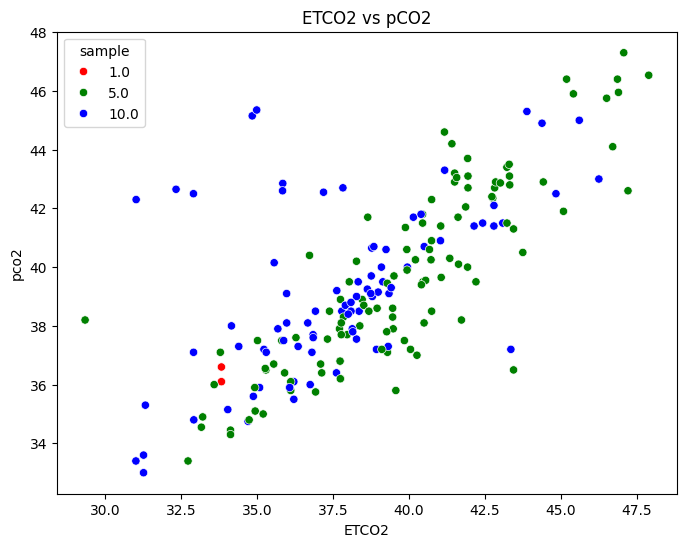

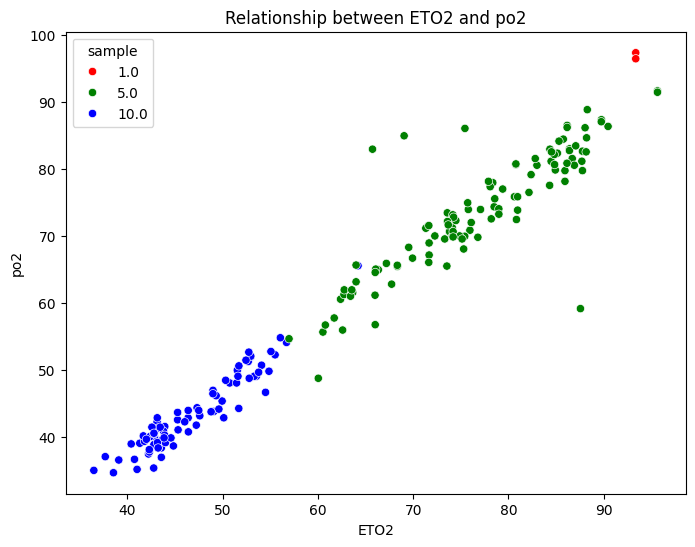

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ETCO2', y='pco2', hue='sample', data=samples_of_interest, palette=custom_palette)
plt.title("ETCO2 vs pCO2")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='ETO2', y='po2', hue='sample', data=samples_of_interest, palette=custom_palette)
plt.title("Relationship between ETO2 and po2")
plt.show()





<div class="alert alert-success">
    
**Exercise**. Select 10 encounters at random. For these encounters, display the evaluation of the saturated O2 blood samples during a desaturation test as a function of the relative time since the start of the desaturation. Give your observations.

</div>

<div class="alert alert-danger">
    
**Advice**. It may be useful to filter out encounters that have a too long duration (too large difference between the maximum datetime and minimum datetime).

</div>

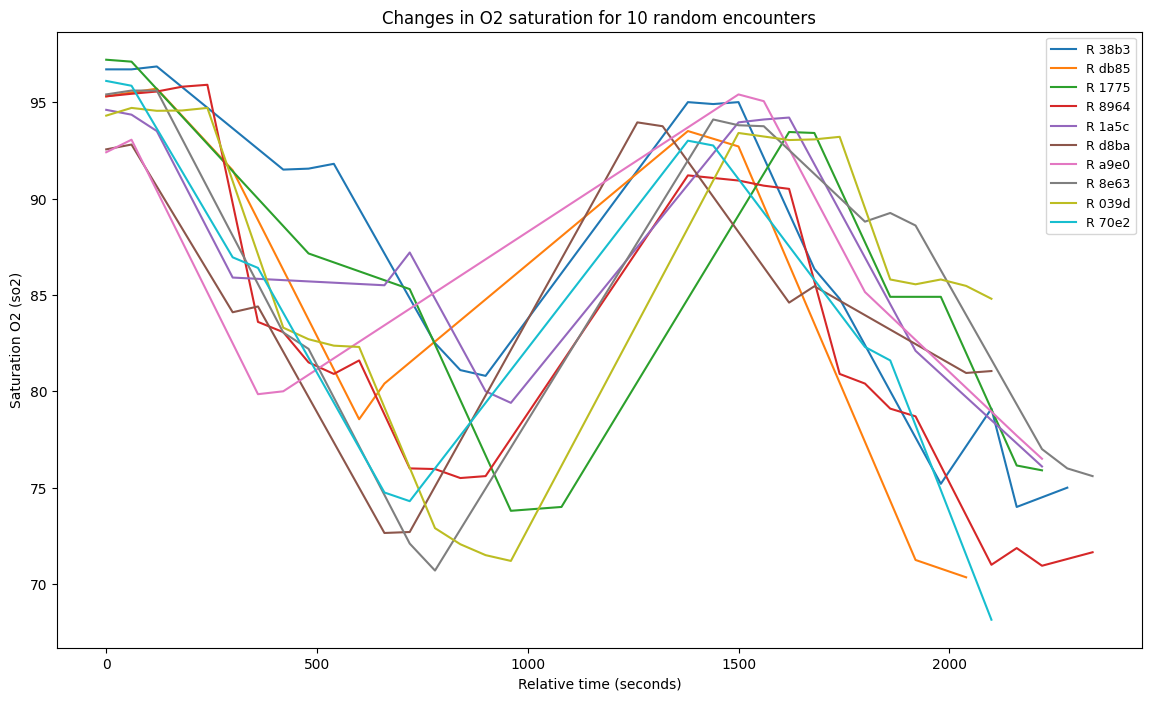

In [12]:
encounter_durations = final_df.groupby('encounter_id')['datetime'].agg(['min', 'max'])
encounter_durations['duration'] = (encounter_durations['max'] - encounter_durations['min']).dt.total_seconds()

filtered_encounters = encounter_durations[
    (encounter_durations['duration'] >= 2000) & (encounter_durations['duration'] <= 3500)
]

random_encounters = filtered_encounters.sample(n=10).index

selected_df = final_df[final_df['encounter_id'].isin(random_encounters)].copy()

selected_df = selected_df.sort_values(by=['encounter_id', 'datetime']).copy()
selected_df.loc[:, 'relative_time'] = selected_df.groupby('encounter_id')['datetime'].transform(
    lambda x: (x - x.min()).dt.total_seconds()
)


plt.figure(figsize=(14, 8))
for encounter_id in random_encounters:
    short_id = str(encounter_id)[:4]
    encounter_data = selected_df[selected_df['encounter_id'] == encounter_id].copy()
    
    plt.plot(encounter_data['relative_time'], encounter_data['so2'], label=f'R {short_id}')


plt.xlabel("Relative time (seconds)")
plt.ylabel("Saturation O2 (so2)")
plt.title("Changes in O2 saturation for 10 random encounters")
plt.legend(fontsize=9) 
plt.show()


The graph shows the evolution of oxygen saturation ($SpO_{2}$) for 10 randomly selected observations. A common trend can be observed in several curves: an initial decrease in saturation followed by an increase, then a further decrease. The maximum values are around 95% and the minimum values sometimes fall below 75%. However, the duration and amplitude of these variations differ between individuals.

<div class="alert alert-success">
    
**Exercise**. Now, load the saturation data from `data/waveforms/{ENCOUNTER_ID[0]}/{ENCOUNTER_ID}_2hz.csv`. Then, also load the infrared PPG data from `data/waveforms/{ENCOUNTER_ID[0]}/{ENCOUNTER_ID}_ppg.dat` using the `wfdb` package.

Only focus on the first 17 minutes of the time series. Beware that they use different sampling frequencies.
    
</div>

In [13]:
ENCOUNTER_ID = '0241a26f4be08b7312eab3099fb7e044376d7d433d69cc15ed67742b0ecf95f5'

In [14]:
saturation_file = f"data/waveforms/{ENCOUNTER_ID[0]}/{ENCOUNTER_ID}_2hz.csv"
saturation_data = pd.read_csv(saturation_file)

max_points_saturation = 17 * 60 * 2
saturation_data = saturation_data.iloc[:max_points_saturation]

ppg_file = f"data/waveforms/{ENCOUNTER_ID[0]}/{ENCOUNTER_ID}_ppg"
ppg_record = wf.rdrecord(ppg_file)

ppg_data = ppg_record.p_signal[:, 0]
ppg_sampling_rate = ppg_record.fs

max_points_ppg = int(17 * 60 * ppg_sampling_rate)
ppg_data = ppg_data[:max_points_ppg]

saturation_time = np.arange(0, len(saturation_data)) / 2 
ppg_time = np.arange(0, len(ppg_data)) / ppg_sampling_rate 

<div class="alert alert-success">
    
**Exercise**. Knowing the sampling rates of the two time series, match them and plot them together on the same figure. Give your observations.

</div>

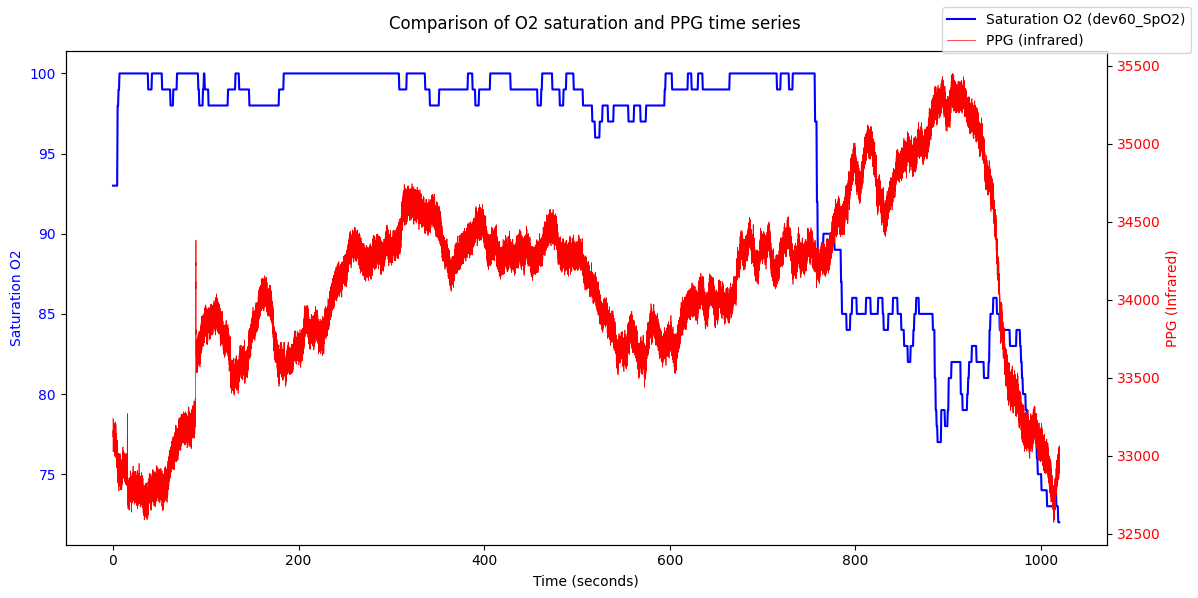

In [15]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(saturation_time, saturation_data['dev60_SpO2'], label="Saturation O2 (dev60_SpO2)", color='blue')
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Saturation O2", color='blue')
ax1.tick_params(axis='y',labelcolor='blue')


ax2 = ax1.twinx()
ax2.plot(ppg_time, ppg_data, label="PPG (infrared)", color='red', linewidth=0.5)
ax2.set_ylabel("PPG (Infrared)", color='red')
ax2.tick_params(axis='y',labelcolor='red')

fig.legend()
fig.suptitle("Comparison of O2 saturation and PPG time series")
fig.tight_layout()
plt.show()


This graph compares the oxygen saturation measured by the sensor (`dev60_SpO2`) with the PPG infrared signal, used to estimate this saturation. We can see that when $SpO_{2}$ decreases, the PPG signal also decreases overall, confirming that they are related.

This corresponds well with what we saw in the correlation matrix, where certain variables related to oxygen (such as `po2`, `so2`, and `ETO2`) already showed very strong relationships between them. Here too, we observe consistency: the raw signal (PPG) generally follows the same trend as $SpO_{2}$ saturation.

However, we note that there is a slight time lag between the infrared signal values and the saturation values.